In [1]:
import ipywidgets as widgets
from IPython.display import display
import os

box_layout = widgets.Layout(
    display="flex",
    flex_flow="column",
    align_items="center",
    border="1px solid #E0E0E0",
    width="400px",
    padding="25px",
    border_radius="10px"
)

button_layout = widgets.Layout(width="100%", height="40px")

upload_layout = widgets.Layout(width="100%")

title = widgets.HTML(
    "<h3 style='margin-bottom:10px;'>Upload CSV Files 👇</h3>"
)

subtitle = widgets.HTML(
    "<p style='color:gray; margin-top:0;'>Select one or more CSV files to upload and save</p>"
)

train_uploader = widgets.FileUpload(
    accept='.csv',
    multiple=True,
    layout=upload_layout
)

save_button = widgets.Button(
    description='Save Files',
    button_style='primary',
    icon='save',
    layout=button_layout
)

status = widgets.HTML("<p style='color:gray;'>Waiting for upload...</p>")

output = widgets.Output()

def save_files(change=None):
    with output:
        output.clear_output()
        
        if train_uploader.value:
            saved_files = []
            for filename, file_info in train_uploader.value.items():
                with open(filename, "wb") as f:
                    f.write(file_info['content'])
                saved_files.append(filename)
            
            status.value = f"<p style='color:green;'>Saved {len(saved_files)} file(s) 👍</p>"
        else:
            status.value = "<p style='color:red;'>⚠️ No files uploaded yet</p>"

train_uploader.observe(save_files, names='value')

save_button.on_click(save_files)

card = widgets.VBox(
    [title, subtitle, train_uploader, save_button, status],
    layout=box_layout
)

display(card)
display(output)

Output()

In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv('file.csv')

In [4]:
df.sample(5)

,Gender,Height,Weight
9244,Female,63.347580,134.977374
536,Male,74.388012,217.143790
212,Male,72.394480,208.436509
1768,Male,72.461528,223.315510
6934,Female,60.858990,114.214034


In [5]:
df.shape

(10000, 3)

<Axes: xlabel='Height', ylabel='Density'>

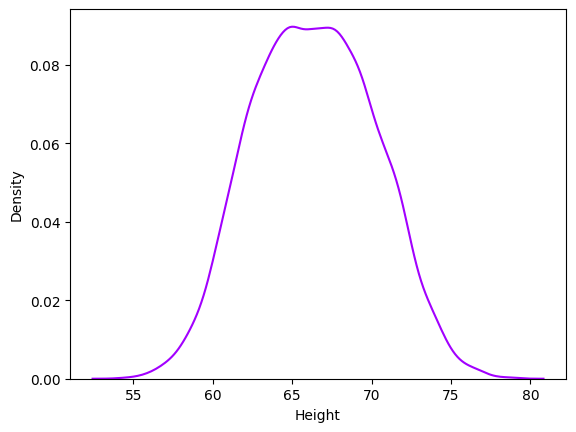

In [6]:
import seaborn as sb
sb.kdeplot(data=df['Height'], color="#a200ff")

<Axes: xlabel='Height'>

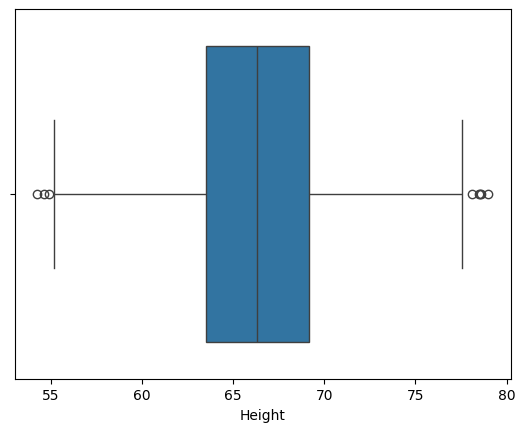

In [7]:
sb.boxplot(data=df, x='Height')

### **Implementing winsorization**

In [10]:
upper_limit = df['Height'].quantile(0.99)
lower_limit = df['Height'].quantile(0.01)

print(f'''Upper limit = {upper_limit.__round__(3)}
Lower limit = {lower_limit.__round__(3)}''')

Upper limit = 74.786
Lower limit = 58.134


### **Outliers**

In [11]:
outliers = df[(df['Height'] > upper_limit) | (df['Height'] < lower_limit)]
outliers

,Gender,Height,Weight
23,Male,75.205974,228.761781
190,Male,76.709835,235.035419
197,Male,75.944460,231.924749
202,Male,75.140821,224.124271
215,Male,74.795375,232.635403
...,...,...,...
9761,Female,56.975279,90.341784
9825,Female,55.979198,85.417534
9895,Female,57.740192,93.652957
9904,Female,57.028857,101.202551


### **Trimming**

In [12]:
new_df = df[(df['Height'] <= upper_limit) & (df['Height'] >= lower_limit)]

### **Result**

<Axes: xlabel='Height'>

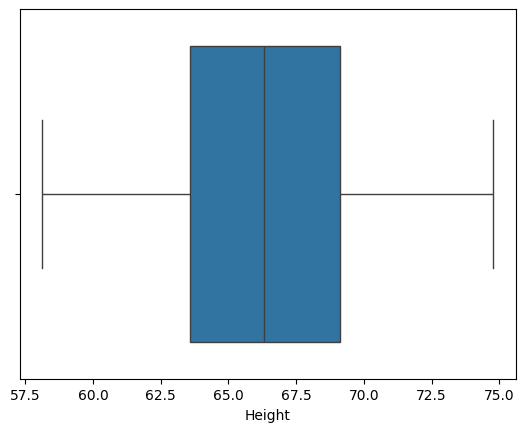

In [13]:
sb.boxplot(data=new_df, x='Height')

### **Capping**

In [14]:
df['Height'] = np.where(df['Height'] >= upper_limit,
        upper_limit,
        np.where(df['Height'] <= lower_limit,
        lower_limit,
        df['Height']))

### **Result**

<Axes: xlabel='Height'>

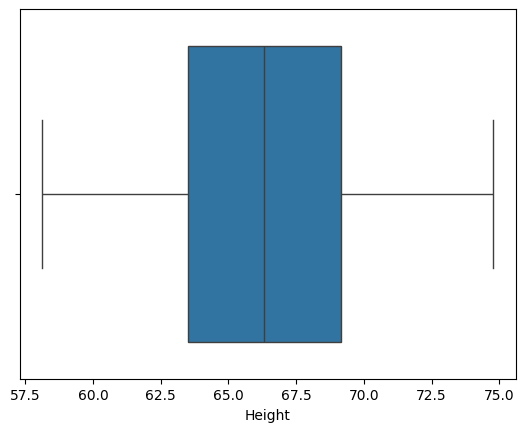

In [15]:
sb.boxplot(data=df, x='Height')